In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/merged_players.csv")

df.head()

,player_id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,2018-08-02,27,2020-09-05,29,200,100.0,Not available,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2018-08-02,27,2020-09-05,29,200,100.0,Not available,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,2018-08-02,27,2020-09-05,29,200,100.0,Not available,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,2018-08-02,27,2020-09-05,29,200,100.0,Not available,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,2002-03-30,17,2020-10-24,36,182,87.0,Not available,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"


In [4]:
df.shape

(25077, 70)

In [5]:
df.columns

Index(['player_id', 'year', 'team', 'is_finals', 'games_played', 'kicks',
       'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs',
       'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers',
       'free_kicks_for', 'free_kicks_against', 'brownlow_votes',
       'contested_possessions', 'uncontested_possessions', 'contested_marks',
       'marks_inside_50', 'one_percenters', 'bounces', 'goal_assists',
       'total_score', 'total_fantasy_points', 'total_percentage_played',
       'avg_kicks', 'avg_marks', 'avg_handballs', 'avg_disposals', 'avg_goals',
       'avg_behinds', 'avg_hit_outs', 'avg_tackles', 'avg_rebound_50s',
       'avg_inside_50s', 'avg_clearances', 'avg_clangers',
       'avg_free_kicks_for', 'avg_free_kicks_against',
       'avg_contested_possessions', 'avg_uncontested_possessions',
       'avg_contested_marks', 'avg_marks_inside_50', 'avg_one_percenters',
       'avg_bounces', 'avg_goal_assists', 'avg_score', 'avg_fantasy_points',
       

**Question 1  Which teams have played the most games?**

In [6]:
games_by_team = df.groupby("team")["games_played"].sum()

games_by_team = games_by_team.sort_values(ascending=False)

games_by_team.head(10)

,games_played
team,
Geelong Cats,16834
West Coast Eagles,16518
Essendon Bombers,16462
North Melbourne Kangaroos,16336
Collingwood Magpies,16298
Sydney Swans,16173
St Kilda Saints,16116
Western Bulldogs,16080
Adelaide Crows,16018


**Chart**

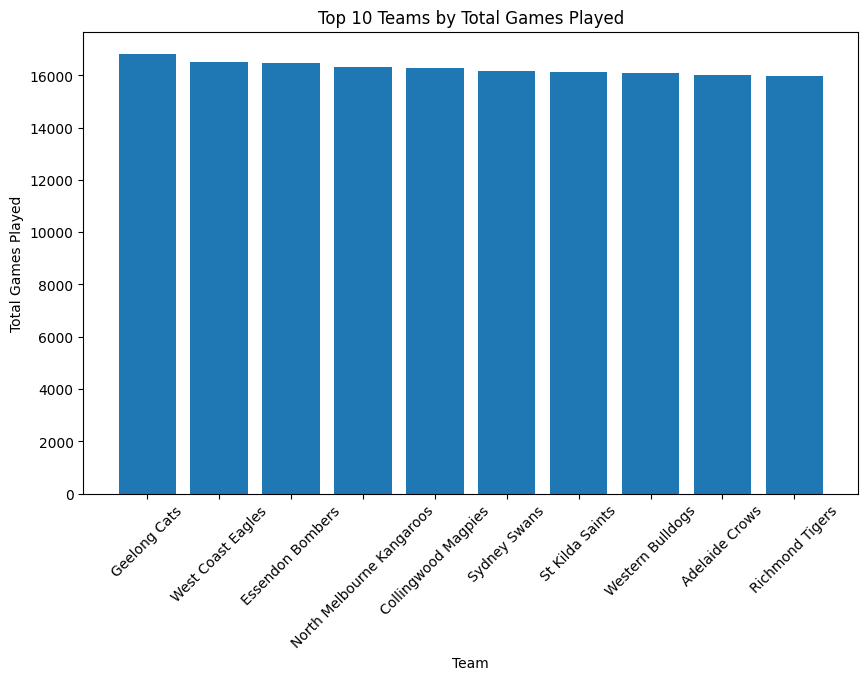

In [7]:
top_10_games = games_by_team.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_games.index,
    top_10_games.values
)

plt.title("Top 10 Teams by Total Games Played")
plt.xlabel("Team")
plt.ylabel("Total Games Played")

plt.xticks(rotation=45)

plt.show()

**Observations**
Geelong Cats have the highest total games played.
Geelong Cats have approximately 16,834 games in the dataset.
Other top teams also have high game totals, showing strong historical representation.
**Business Insight**

Teams with more accumulated games have more historical data available, making them useful for long-term team performance analysis

**Question 2 — What is the distribution of player ages?**

In [8]:
df["last_age"].describe()

,last_age
count,25077.000000
mean,28.775811
std,3.880429
min,18.000000
25%,26.000000
50%,29.000000
75%,32.000000
max,40.000000


**Histogram**

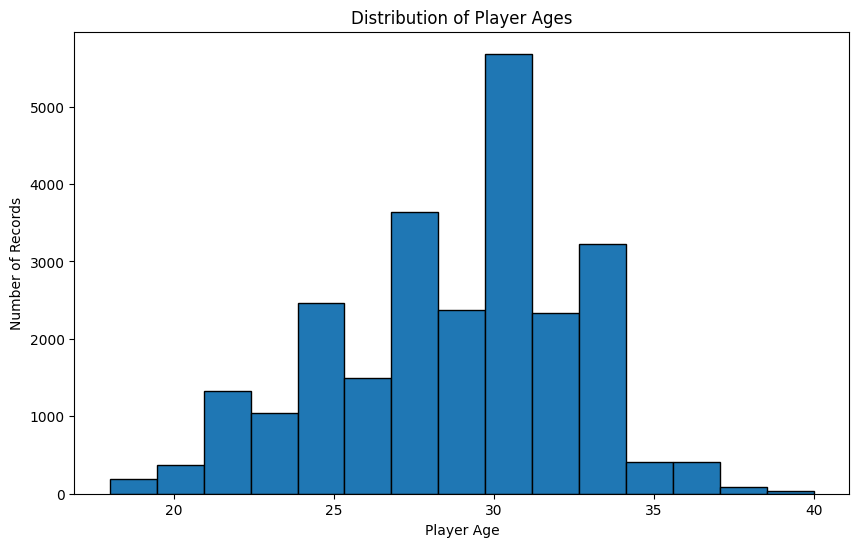

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["last_age"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Player Ages")
plt.xlabel("Player Age")
plt.ylabel("Number of Records")

plt.show()

**Observations**
Player ages range approximately from 18 to 40 years.
Median player age is approximately 29 years.
Most player records are concentrated around the mid-to-late 20s and early 30s.
**Business Insight**

Most players are represented during their established playing years, so teams can use age patterns when comparing player experience and performance.

**Question 3 — Which teams have the highest number of players?**

In [10]:
from collections import defaultdict

unique_players = df[
    ["player_id", "player_teams"]
].drop_duplicates()

team_players = defaultdict(set)

for _, row in unique_players.iterrows():

    teams = row["player_teams"]

    if pd.isna(teams) or teams == "Not available":
        continue

    teams = str(teams).strip("{}")

    for team in teams.split(","):

        team = team.strip()

        if team:
            team_players[team].add(row["player_id"])
players_by_team = pd.Series({
    team: len(players)
    for team, players in team_players.items()
})

players_by_team = players_by_team.sort_values(
    ascending=False
)

players_by_team.head(10)

,0
Carlton Blues,250
Collingwood Magpies,243
Essendon Bombers,239
North Melbourne Kangaroos,237
Brisbane Lions,232
Richmond Tigers,231
St Kilda Saints,229
Hawthorn Hawks,220
Melbourne Demons,219
West Coast Eagles,219


**Chart**

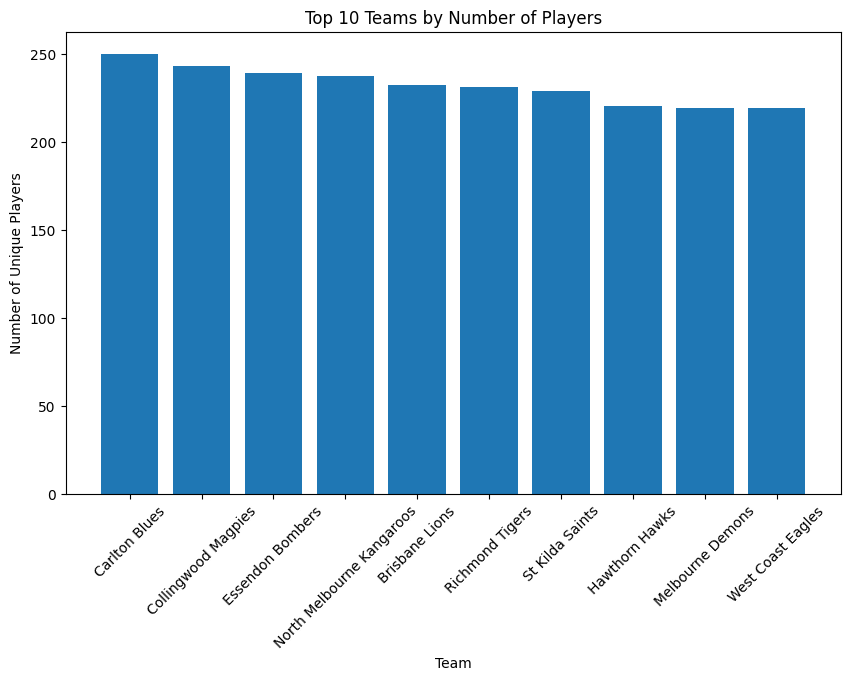

In [11]:
top_10_players = players_by_team.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_players.index,
    top_10_players.values
)

plt.title("Top 10 Teams by Number of Players")
plt.xlabel("Team")
plt.ylabel("Number of Unique Players")

plt.xticks(rotation=45)

plt.show()

**Observations**
Carlton Blues have the highest number of unique players.
Carlton Blues are associated with approximately 250 unique players.
Several other teams also have large historical player pools.
**Business Insight**

Teams with larger historical player pools provide more player data for recruitment, player comparison and talent analysis.

**Question 4 — How does player weight vary across teams?**

In [12]:
weight_by_team = df.groupby("team")["weight"].mean()

weight_by_team = weight_by_team.sort_values(
    ascending=False
)

weight_by_team

,weight
team,
Geelong Cats,89.073302
Brisbane Bears,88.429688
Collingwood Magpies,88.360985
West Coast Eagles,88.323350
Brisbane Lions,88.312233
Fremantle Dockers,88.062117
Essendon Bombers,87.865908
Sydney Swans,87.742217
St Kilda Saints,87.738726


**Chart**

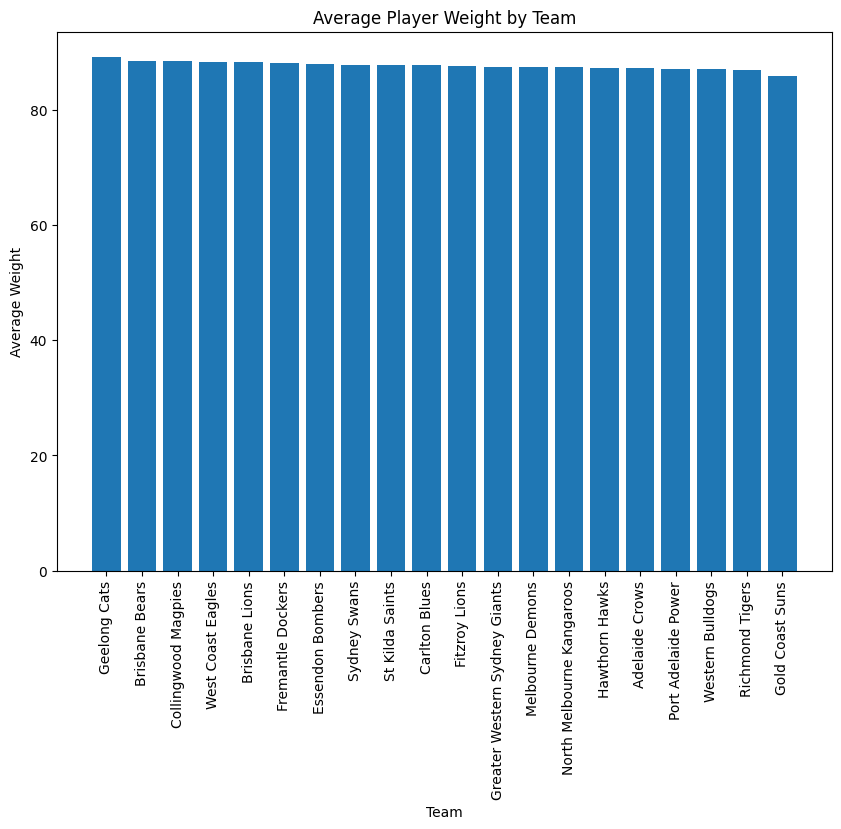

In [13]:
plt.figure(figsize=(10, 7))

plt.bar(
    weight_by_team.index,
    weight_by_team.values
)

plt.title("Average Player Weight by Team")
plt.xlabel("Team")
plt.ylabel("Average Weight")

plt.xticks(rotation=90)

plt.show()

**Observation**
1. The chart shows differences in average player weight between teams.
2. Some teams have slightly heavier player groups than others.
3. However, average weights across most teams are relatively close.

**Business Insight**

Average weight helps compare the physical profiles of teams and can support analysis of squad composition.

**Question 5 — Which teams have highest average fantasy points?**

In [14]:
fantasy_by_team = df.groupby(
    "team"
)["avg_fantasy_points"].mean()

fantasy_by_team = fantasy_by_team.sort_values(
    ascending=False
)

fantasy_by_team.head(10)

,avg_fantasy_points
team,
Hawthorn Hawks,62.624304
Greater Western Sydney Giants,62.546269
Geelong Cats,62.183194
Collingwood Magpies,60.882242
St Kilda Saints,60.576951
Essendon Bombers,60.312966
Adelaide Crows,60.080962
Western Bulldogs,59.948072
Fremantle Dockers,59.914647


**Chart**

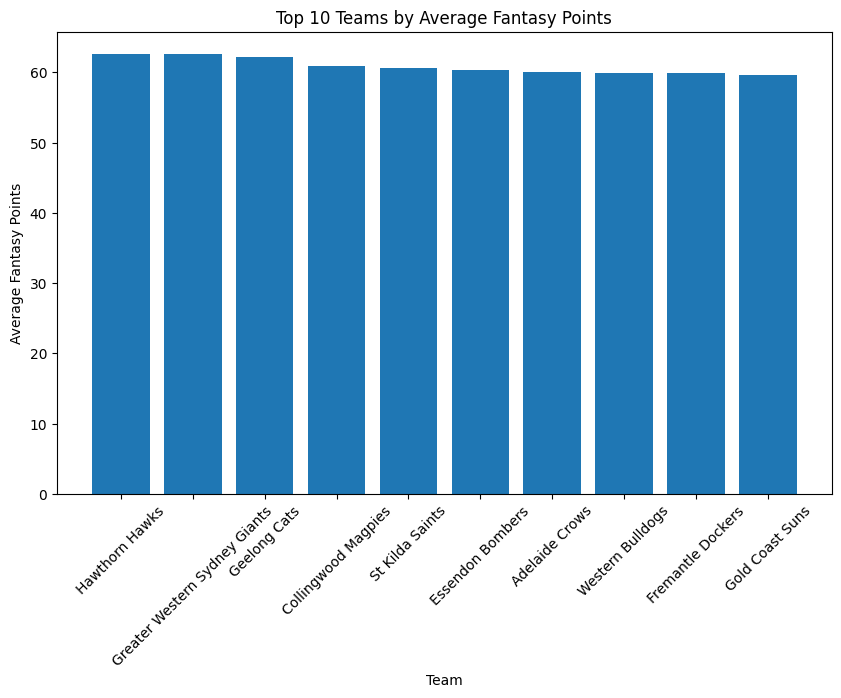

In [15]:
top_10_fantasy = fantasy_by_team.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_10_fantasy.index,
    top_10_fantasy.values
)

plt.title("Top 10 Teams by Average Fantasy Points")
plt.xlabel("Team")
plt.ylabel("Average Fantasy Points")

plt.xticks(rotation=45)

plt.show()

**Observations**
1. Hawthorn Hawks have the highest average fantasy points.
2. Their average is approximately 62.62 fantasy points.
3. The top teams show stronger average statistical performance than lower-ranked teams.

**Business Insight**

Fantasy points provide a useful overall performance measure and can help identify teams whose players consistently produce strong statistics

**Question 6 — Who are the Top 15 goal scorers?**

In [16]:
top_15_scorers = (
    df.groupby("player_full_name")["goals"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_15_scorers

,goals
player_full_name,
Tony_Lockett,1360.0
Lance_Franklin,1066.0
Matthew_Lloyd0,926.0
Matthew_Richardson,800.0
Tom_Hawkins,796.0
Jack_Riewoldt,787.0
Saverio_Rocca,748.0
Barry_Hall,746.0
Jeremy_Cameron,736.0


**Chart**

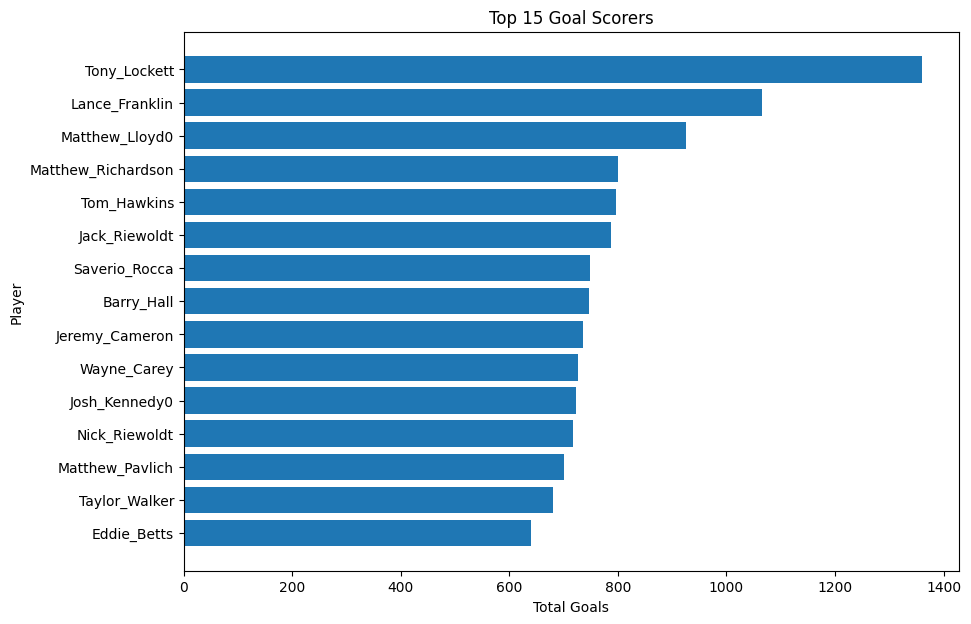

In [17]:
top_15_scorers = top_15_scorers.sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_15_scorers.index,
    top_15_scorers.values
)

plt.title("Top 15 Goal Scorers")
plt.xlabel("Total Goals")
plt.ylabel("Player")

plt.show()

**Observations**
1. Tony Lockett is the highest goal scorer.
2. He has approximately 1,360 goals in the merged dataset.
3. The Top 15 players represent the strongest historical goal-scoring performers in the dataset.
**Business Insight**

Top goal scorers can be used as benchmarks when comparing the attacking performance of other players.

**Question 7 — How many records are available for each season?**

In [18]:
records_per_season = df["year"].value_counts()

records_per_season = records_per_season.sort_index()

records_per_season

,count
year,
1983,2
1984,2
1985,7
1986,15
1987,29
1988,52
1989,71
1990,93
1991,136


**Chart**

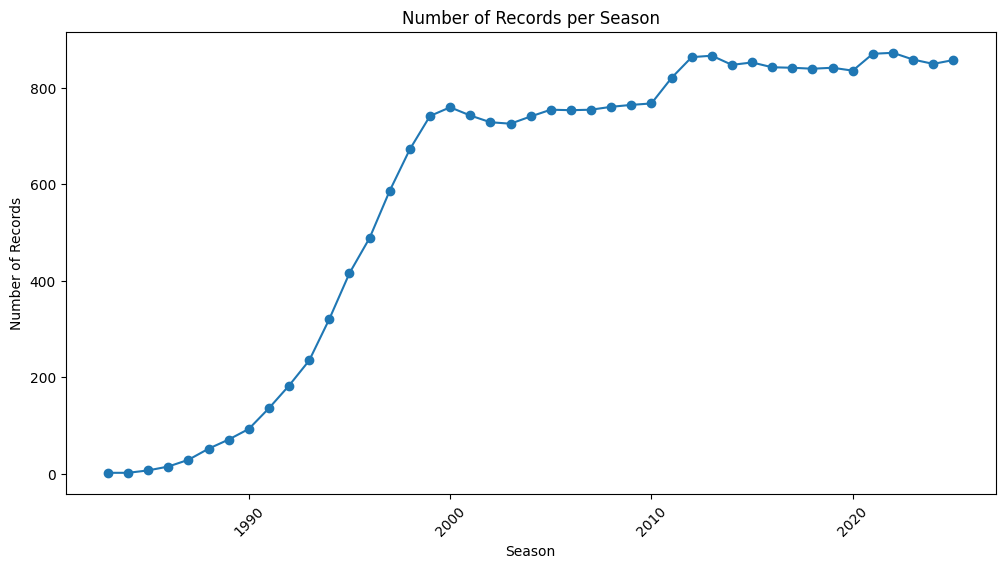

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    records_per_season.index,
    records_per_season.values,
    marker="o"
)

plt.title("Number of Records per Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.show()

**Observations**
1. Earlier seasons contain fewer records than recent seasons.
2. The number of records generally increases over time.
3. 2022 has the highest number of records, approximately 873.

**Business Insight**

Recent seasons contain more data, making recent-season analysis more reliable and detailed than analysis of the earliest seasons.